> **Superseded exploratory notebook** — groundwork for secondary-dataset enrichment (Amazon rank, UCSD, adaptations). Not part of the final modelling pipeline; see `EDA/book_success_merge.ipynb` and `methodology/design.md` for the canonical pipeline.

In [10]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd())  + '/scripts_local')
# if running from scripts_local/ directly:
if os.path.basename(os.getcwd()) == 'scripts_local':
    sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.io import load_goodbooks, load_amazon_popular, load_amazon_rank_index, load_nyt_bestsellers, load_books_into_movies
from utils.joining import normalize_isbn13, normalize_isbn10
from utils.plotting import apply_style, save_fig, COLOR_PALETTE
from utils.paths import FIGURES_DIR

apply_style()
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 80)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1  GoodBooks-10k Extended
Primary base table: 10,000 books with ratings, genres, descriptions, and ISBNs.

In [11]:
gb = load_goodbooks()
print(f"Shape: {gb.shape}")
gb.head(3)

Shape: (10000, 29)


,index,authors,average_rating,best_book_id,book_id,books_count,description,genres,goodreads_book_id,image_url,isbn,isbn13,language_code,original_publication_year,original_title,pages,publishDate,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,ratings_count,small_image_url,title,work_id,work_ratings_count,work_text_reviews_count,authors_2
0,0,[Suzanne Collins],4.34,2767052,1,272,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES H...,"[young-adult, fiction, fantasy, science-fiction, romance]",2767052,https://images.gr-assets.com/books/1447303603m/2767052.jpg,439023483,9.780439e+12,eng,2008.0,The Hunger Games,374.0,09/14/08,66715,127936,560092,1481305,2706317,4780653,https://images.gr-assets.com/books/1447303603s/2767052.jpg,"The Hunger Games (The Hunger Games, #1)",2792775,4942365,155254,[Suzanne Collins]
1,1,"[J.K. Rowling, Mary GrandPré]",4.44,3,2,491,Harry Potter's life is miserable. His parents are dead and he's stuck with h...,"[fantasy, fiction, young-adult, classics]",3,https://images.gr-assets.com/books/1474154022m/3.jpg,439554934,9.780440e+12,eng,1997.0,Harry Potter and the Philosopher's Stone,309.0,11/01/03,75504,101676,455024,1156318,3011543,4602479,https://images.gr-assets.com/books/1474154022s/3.jpg,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",4640799,4800065,75867,"[J.K. Rowling, Mary GrandPré]"
2,2,[Stephenie Meyer],3.57,41865,3,226,"About three things I was absolutely positive.\n\nFirst, Edward was a vampire...","[young-adult, fantasy, romance, fiction, paranormal]",41865,https://images.gr-assets.com/books/1361039443m/41865.jpg,316015849,9.780316e+12,eng,2005.0,Twilight,501.0,09/06/06,456191,436802,793319,875073,1355439,3866839,https://images.gr-assets.com/books/1361039443s/41865.jpg,"Twilight (Twilight, #1)",3212258,3916824,95009,[Stephenie Meyer]


In [12]:
# Identifier completeness
for col in ('isbn', 'isbn13', 'goodreads_book_id'):
    n = gb[col].notna().sum()
    print(f"{col}: {n}/{len(gb)} non-null ({n/len(gb):.1%})")

isbn: 9300/10000 non-null (93.0%)
isbn13: 9415/10000 non-null (94.2%)
goodreads_book_id: 10000/10000 non-null (100.0%)


Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/01_goodbooks_distributions.png


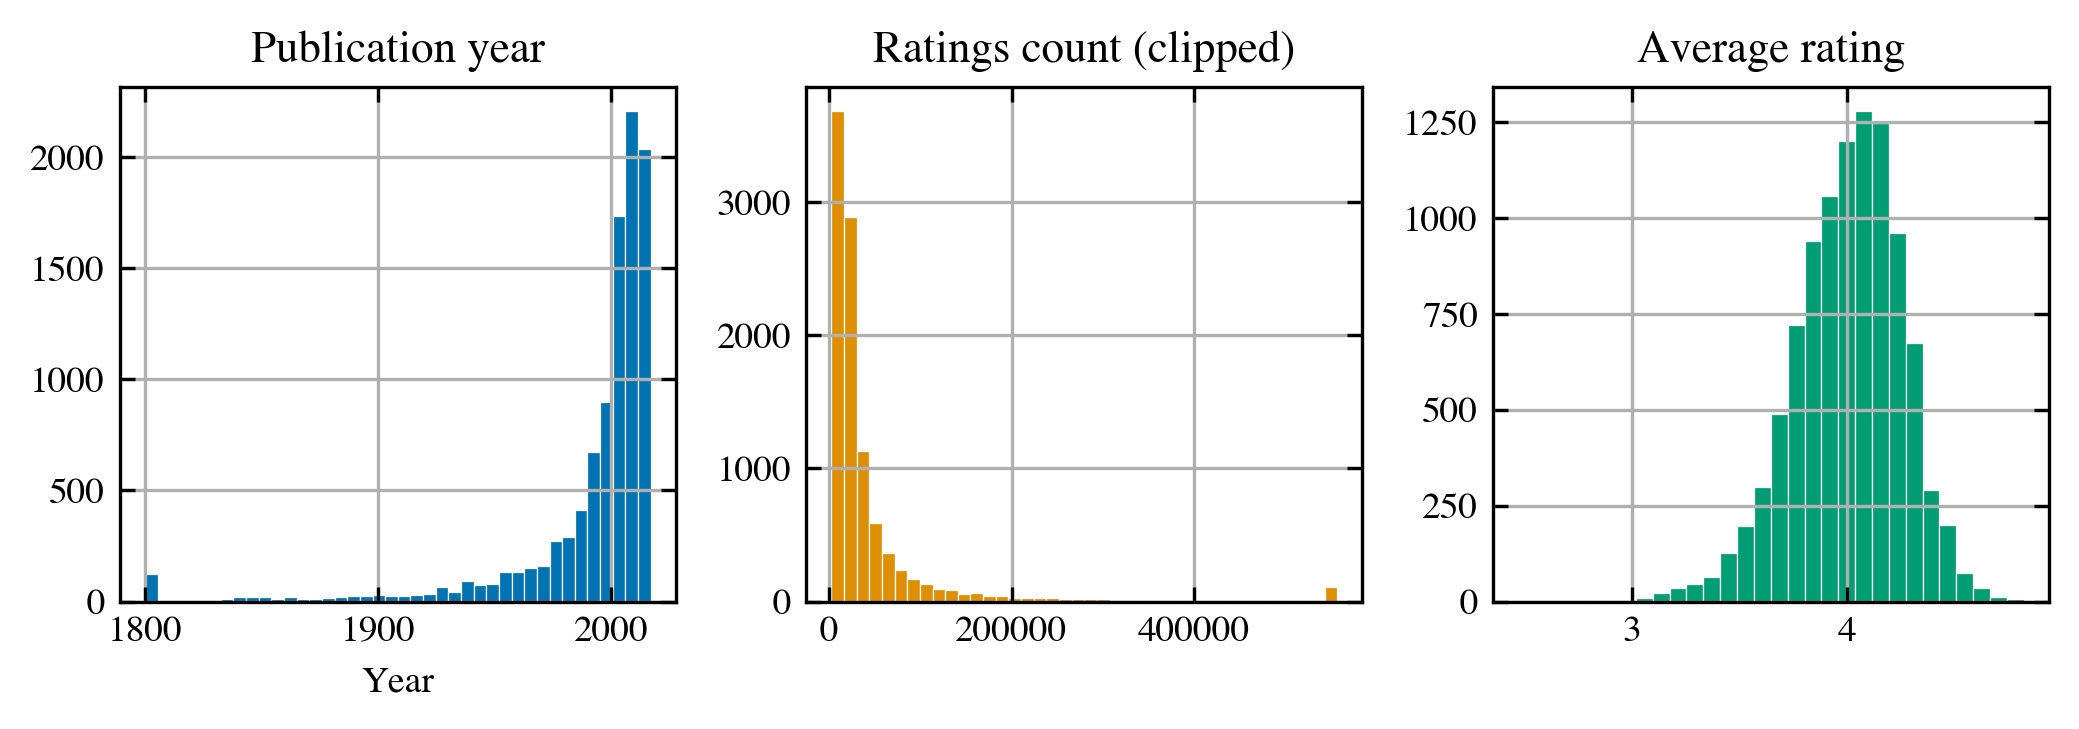

In [13]:
# Key metadata distributions
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

gb['original_publication_year'].dropna().clip(1800, 2025).hist(
    ax=axes[0], bins=40, color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Publication year')
axes[0].set_xlabel('Year')

gb['ratings_count'].clip(upper=gb['ratings_count'].quantile(0.99)).hist(
    ax=axes[1], bins=40, color=COLOR_PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Ratings count (clipped)')

gb['average_rating'].hist(
    ax=axes[2], bins=30, color=COLOR_PALETTE[2], edgecolor='white', linewidth=0.3)
axes[2].set_title('Average rating')

plt.tight_layout()
save_fig('01_goodbooks_distributions.png', FIGURES_DIR)

## 2  Amazon Popular Books Dataset
~2,270 highly-reviewed books with price, reviews count, and ASIN.

In [14]:
amz = load_amazon_popular()
print(f"Shape: {amz.shape}")
amz[['asin', 'ISBN10', 'title', 'rating', 'reviews_count', 'final_price', 'categories']].head(5)

Shape: (2269, 40)


,asin,ISBN10,title,rating,reviews_count,final_price,categories
0,0007350813,0007350813,Wuthering Heights (Collins Classics),4.6 out of 5 stars,13451,3.99,"[Books, Literature & Fiction, Genre Fiction]"
1,0007513763,9780007513765,THE DAYS THE CRAYONS QUIT,4.8 out of 5 stars,16628,12.08,"[Books, Children's Books, Literature & Fiction]"
2,0008183988,0008183988,War Lord: Book 13 (The Last Kingdom Series),4.8 out of 5 stars,11275,NaN,"[Books, Literature & Fiction, Genre Fiction]"
3,0008305838,0008305838,Code Name Bananas: The hilarious and epic new children’s book from multi-mil...,4.8 out of 5 stars,15520,20.43,"[Books, Children's Books, Literature & Fiction]"
4,0008375526,0008375526,Skincare: The award-winning ultimate no-nonsense guide and Sunday Times No. ...,4.8 out of 5 stars,10884,28.89,"[Books, Crafts, Hobbies & Home, Home Improvement & Design]"


In [15]:
# Identifier completeness
for col in ('asin', 'ISBN10'):
    n = amz[col].notna().sum()
    nonempty = (amz[col].astype(str).str.strip() != '').sum()
    print(f"{col}: {n} non-null, {nonempty} non-empty")

# Note: ASIN often equals ISBN10 for books
same = (amz['asin'].astype(str) == amz['ISBN10'].astype(str)).sum()
print(f"\nASIN == ISBN10: {same}/{len(amz)} ({same/len(amz):.1%})")

asin: 2269 non-null, 2269 non-empty
ISBN10: 1429 non-null, 2269 non-empty

ASIN == ISBN10: 1234/2269 (54.4%)


Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/01_amazon_popular_distributions.png


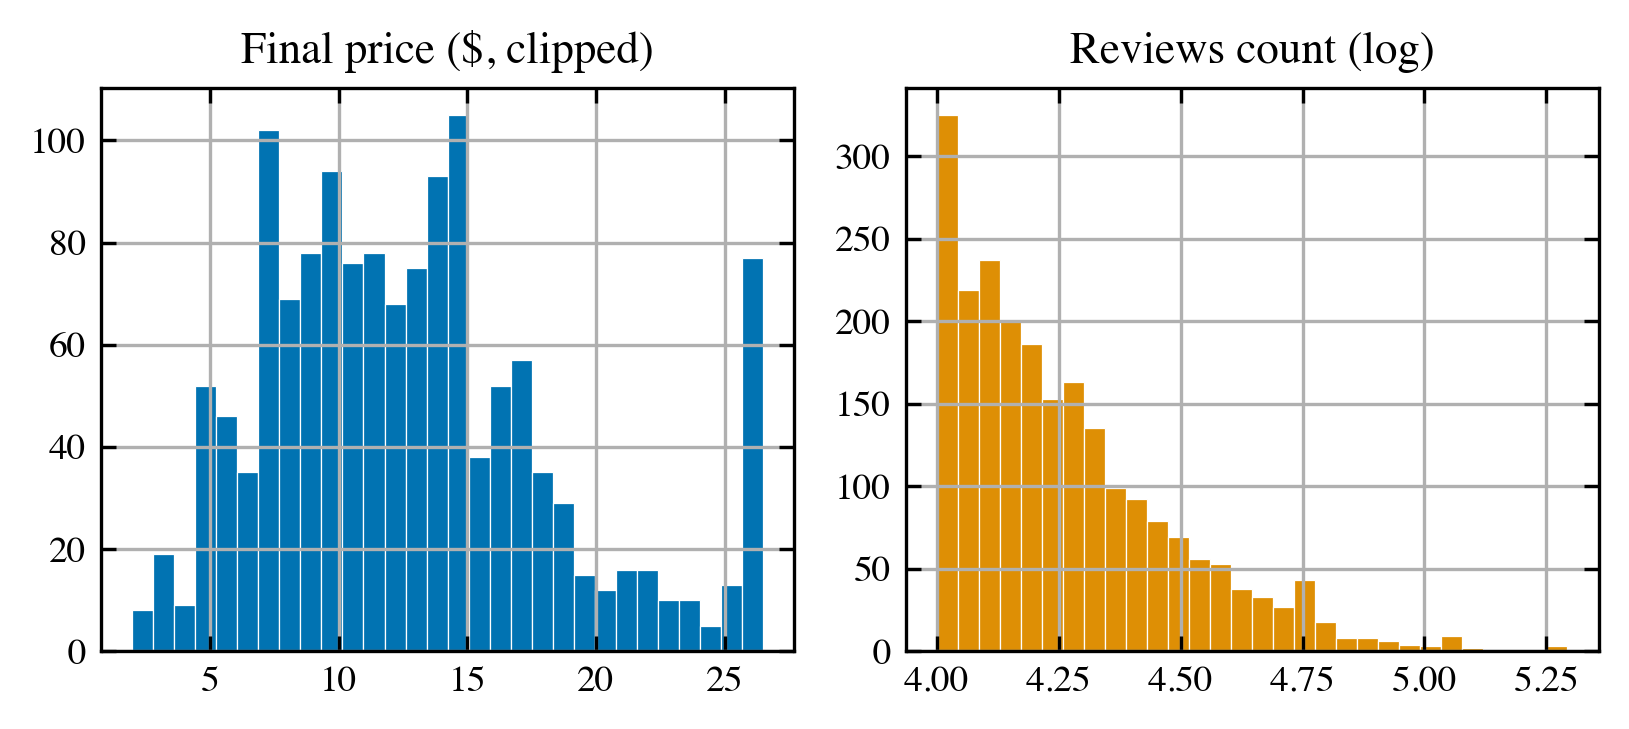

In [16]:
# Price and review count distributions
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))

prices = pd.to_numeric(amz['final_price'], errors='coerce').dropna()
prices.clip(0, prices.quantile(0.95)).hist(
    ax=axes[0], bins=30, color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Final price ($, clipped)')

revs = pd.to_numeric(amz['reviews_count'], errors='coerce').dropna()
np.log10(revs + 1).hist(
    ax=axes[1], bins=30, color=COLOR_PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Reviews count (log)')

plt.tight_layout()
save_fig('01_amazon_popular_distributions.png', FIGURES_DIR)

## 3  Amazon Sales Rank Index
ASIN index with TITLE, AUTHOR, PUBLISHER — links to the per-ASIN rank-history JSON files.

In [17]:
rank_idx = load_amazon_rank_index()
print(f"Shape: {rank_idx.shape}")
rank_idx.head(5)

Shape: (63432, 6)


,asin,group,format,title,author,publisher
0,1250150183,book,hardcover,The Swamp: Washington's Murky Pool of Corruption and Cronyism and How Trump ...,Eric Bolling,St. Martin's Press
1,0778319997,book,hardcover,"Rise and Shine, Benedict Stone: A Novel",Phaedra Patrick,Park Row Books
2,1608322564,book,hardcover,Sell or Be Sold: How to Get Your Way in Business and in Life,Grant Cardone,Greenleaf Book Group Press
3,0310325331,book,hardcover,Christian Apologetics: An Anthology of Primary Sources,"Khaldoun A. Sweis, Chad V. Meister",Zondervan
4,0312616295,book,hardcover,Gravity: How the Weakest Force in the Universe Shaped Our Lives,Brian Clegg,St. Martin's Press


In [18]:
from utils.rank_features import available_rank_asins
rank_asins = available_rank_asins()
print(f"Rank-history files on disk: {len(rank_asins):,}")

# Format breakdown
print("\nFormat counts:")
print(rank_idx['format'].value_counts().head(10))

Rank-history files on disk: 66,760

Format counts:
format
kindle edition           29771
paperback                23075
hardcover                 9731
mass market paperback      853
 Joan Beasley Ph.D.          1
Name: count, dtype: int64


## 4  Identifier Overlap Audit
How many GoodBooks ISBN-10 values appear in Amazon Popular and in the rank-history files?

In [19]:
# Normalise ISBN-10 in both datasets
gb_isbn10 = set(gb['isbn'].apply(normalize_isbn10).dropna())
amz_isbn10 = set(amz['ISBN10'].apply(normalize_isbn10).dropna())

overlap_amz = gb_isbn10 & amz_isbn10
overlap_rank = gb_isbn10 & rank_asins  # ASIN = ISBN10 for books

print(f"GoodBooks ISBNs:        {len(gb_isbn10):,}")
print(f"Amazon Popular ISBNs:   {len(amz_isbn10):,}")
print(f"Overlap (GoodBooks ∩ Amazon Popular): {len(overlap_amz):,} ({len(overlap_amz)/len(gb_isbn10):.1%} of GoodBooks)")
print(f"Overlap (GoodBooks ∩ Sales Rank):     {len(overlap_rank):,} ({len(overlap_rank)/len(gb_isbn10):.1%} of GoodBooks)")

GoodBooks ISBNs:        9,300
Amazon Popular ISBNs:   1,266
Overlap (GoodBooks ∩ Amazon Popular): 99 (1.1% of GoodBooks)
Overlap (GoodBooks ∩ Sales Rank):     950 (10.2% of GoodBooks)


Saved → /Users/dingshandeng/github/3-Project_side/project/scripts_local/figures/01_identifier_coverage.png


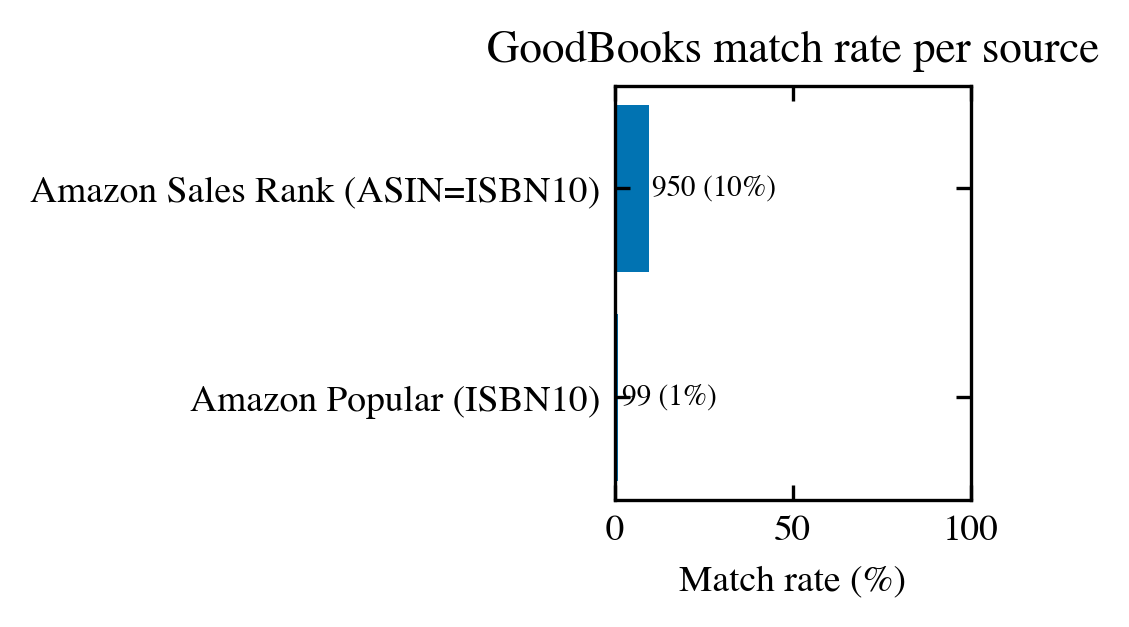

In [20]:
# Visualise identifier coverage
from utils.plotting import coverage_bar

labels = ['Amazon Popular (ISBN10)', 'Amazon Sales Rank (ASIN=ISBN10)']
counts = [len(overlap_amz), len(overlap_rank)]
coverage_bar(labels, counts, total=len(gb), title='GoodBooks match rate per source')
save_fig('01_identifier_coverage.png', FIGURES_DIR)
plt.show()

## 5  Datasets Still Needed
The following datasets have not yet been downloaded. They provide the primary outcome labels.

In [25]:
# This will print download instructions for missing datasets
from utils.io import load_nyt_bestsellers, load_books_into_movies, load_ucsd_books

nyt = load_nyt_bestsellers()
movies = load_books_into_movies()
ucsd = load_ucsd_books(nrows=5)

### Download instructions

**NYT Bestsellers 1931–2020 (Post45)**  
URL: https://data.post45.org/posts/nyt_hardcover_fiction_bestsellers/  
Save as: `/Users/dingshandeng/data_local/data_book/nyt_bestsellers/nyt_full.tsv`

The real data saved as: 
`nyt_hardcover_fiction_bestsellers-lists`

**Books Into Movies (Kaggle)**  
```bash
kaggle datasets download -d padmanabh275/books-into-movies \
  --path /Users/dingshandeng/data_local/data_book/books_into_movies --unzip
```

**UCSD Book Graph**  
URL (updated link): https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html#datasets  
Save the `goodreads_books.json` file as:  
`/Users/dingshandeng/data_local/data_book/ucsd_book_graph/goodreads_books.json`